In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from datasets import Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [2]:
df = pd.read_csv("twitter_training.csv", header=None)

df.columns = [
    "id",
    "topic",
    "sentiment",
    "text"
]

df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
print(df.shape)

df.info()

df.isnull().sum()

(74682, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


id             0
topic          0
sentiment      0
text         686
dtype: int64

In [4]:
df = df.dropna(subset=["text"])

print(df.shape)

(73996, 4)


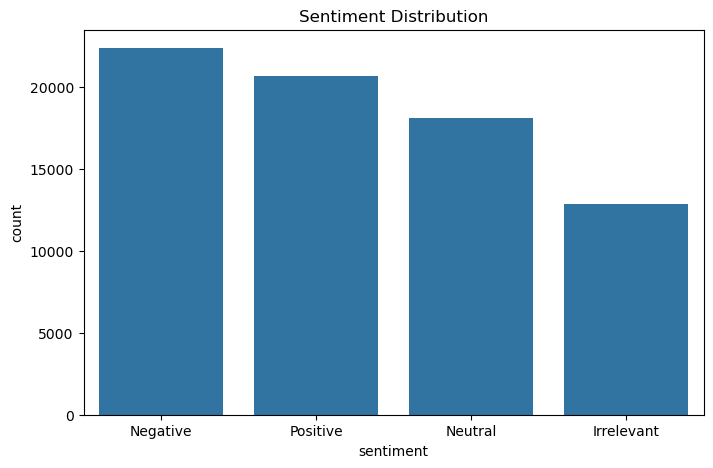

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="sentiment",
    data=df,
    order=df["sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.show()

In [6]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["sentiment"])

print(encoder.classes_)

df.head()

['Irrelevant' 'Negative' 'Neutral' 'Positive']


,id,topic,sentiment,text,label
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,3
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,3
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,3
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,3
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,3


In [ ]:
df = (
    df.groupby("label", group_keys=False)[df.columns]
      .apply(lambda x: x.sample(min(len(x), 500), random_state=42))
      .reset_index(drop=True)
)

print(df.shape)

df["label"].value_counts()


In [8]:
df = df[["text","label"]]

df.head()

,text,label
0,It's good it's like a really good threesome on...,0
1,Great update and talk earlier today at the Spr...,0
2,Love these new @ GhostLive cans!! Does anyone ...,0
3,Social distancing can be sexy!,0
4,I often stay bed ridden due to these complicat...,0


In [9]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(len(train_texts))
print(len(test_texts))

1600
400


In [10]:
train_dataset = Dataset.from_dict({
    "text":train_texts.tolist(),
    "label":train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "text":test_texts.tolist(),
    "label":test_labels.tolist()
})

In [11]:
model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)

In [12]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [13]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [15]:
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(encoder.classes_)
)

print("Model Loaded")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded


In [ ]:
# Save label mapping into the model config so the PyQt app (and anyone
# loading this model later) knows which index maps to which sentiment name.
label2id = {label: int(idx) for idx, label in enumerate(encoder.classes_)}
id2label = {int(idx): label for idx, label in enumerate(encoder.classes_)}

model.config.label2id = label2id
model.config.id2label = id2label

print("label2id:", label2id)
print("id2label:", id2label)


In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [17]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    num_train_epochs=1,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    weight_decay=0.01,

    logging_steps=20,

    report_to="none"
)

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [19]:
trainer.train()

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.304575,1.287620,0.432500,0.434211,0.432500,0.428414


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=100, training_loss=1.348637809753418, metrics={'train_runtime': 1832.8836, 'train_samples_per_second': 0.873, 'train_steps_per_second': 0.055, 'total_flos': 105246312038400.0, 'train_loss': 1.348637809753418, 'epoch': 1.0})

In [20]:
results = trainer.evaluate()

print(results)

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.304575,1.287620,1,0.432500,0.434211,0.432500,0.428414


{'eval_loss': 1.2876195907592773, 'eval_accuracy': 0.4325, 'eval_precision': 0.43421063994824644, 'eval_recall': 0.4325, 'eval_f1': 0.42841405522867104}


In [ ]:
# Training vs validation loss, and training vs validation accuracy,
# pulled from the Trainer's log history (required by the assignment).
log_history = trainer.state.log_history

train_loss = [(h["step"], h["loss"]) for h in log_history if "loss" in h]
eval_loss = [(h["epoch"], h["eval_loss"]) for h in log_history if "eval_loss" in h]
eval_acc = [(h["epoch"], h["eval_accuracy"]) for h in log_history if "eval_accuracy" in h]

plt.figure(figsize=(8, 5))
if train_loss:
    steps, losses = zip(*train_loss)
    plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

if eval_loss:
    epochs, losses = zip(*eval_loss)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, losses, marker="o", label="Validation Loss", color="orange")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss per Epoch")
    plt.legend()
    plt.show()

if eval_acc:
    epochs, accs = zip(*eval_acc)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, accs, marker="o", label="Validation Accuracy", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy per Epoch")
    plt.legend()
    plt.show()


In [21]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = test_labels.to_numpy()

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [22]:
print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

  Irrelevant       0.31      0.29      0.30       100
    Negative       0.50      0.53      0.51       100
     Neutral       0.43      0.55      0.48       100
    Positive       0.50      0.36      0.42       100

    accuracy                           0.43       400
   macro avg       0.43      0.43      0.43       400
weighted avg       0.43      0.43      0.43       400



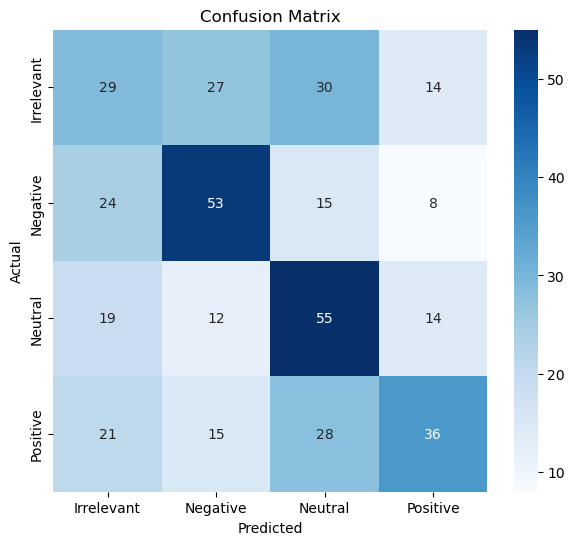

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
model.save_pretrained("saved_bert_model")
tokenizer.save_pretrained("saved_bert_model")

print("Model Saved Successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully!


In [25]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    sentiment = encoder.inverse_transform([prediction])[0]

    return sentiment

In [26]:
print("Prediction 1:", predict_sentiment("I love this game."))

print("Prediction 2:", predict_sentiment("This update is terrible."))

print("Prediction 3:", predict_sentiment("The gameplay is average."))

print("Prediction 4:", predict_sentiment("The company announced a new product."))

Prediction 1: Positive
Prediction 2: Negative
Prediction 3: Negative
Prediction 4: Negative


In [27]:
print(predict_sentiment("I love this game"))

Positive
